### Multiplane Holography

The previous `slmsuite` examples have examined holography powered by discrete Fourier transforms (DFTs)
and by "compressed" Zernike kernels. We now examine a sort of meta holography
which "bakes" many simple objectives into a single hologram. These objectives can span 
planes of focus (DFTs or spots at different $z$ positions), 
planes of color (DFT grids or kernels scaled for different wavelengths), 
planes of basis (combining DTF and kernel objectives into the same hologram), 
or more!


#### Initialization

To start, we initialize our system:

In [1]:
# Header. This is hidden from sphinx with the json metadata:
#   {"nbsphinx":"hidden"}

# ipython configuration (reloads source code automatically and plots inline)
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc('image', cmap='inferno')

from slmsuite.hardware.cameraslms import FourierSLM

[INF] 17:40:25 PLM Initialized PLM on display 2.
[INF] 17:40:29 FLIR Cam Initialized FLIR.
[INF] 17:40:30 FLIR Cam-PLM Initialized FourierSLM.
[INF] 17:40:30 FLIR Cam-PLM Loaded 'pixel' calibration from 'slm2_pixel_calibration_1-5V.h5'.
[INF] 17:40:30 FLIR Cam-PLM Loaded 'wavefront' calibration from 'slm2_superpixel_calibration_offset=0-25_wav=488.h5'.
[WRN] 17:40:30 FLIR Cam-PLM remove_background is enabled and a noise floor was detected; removing this background (4.2% of the average normalization).


smooth: 100%|██████████| 16/16 [00:00<00:00, 28.28it/s]


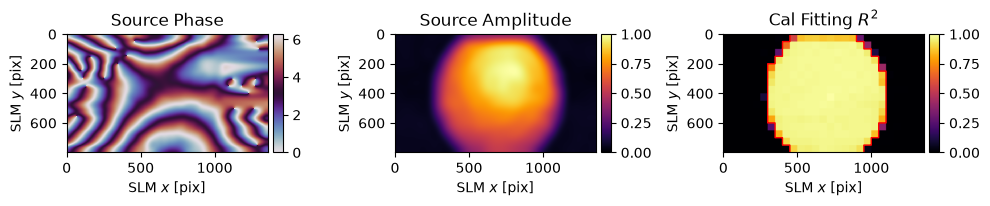

[WRN] 17:40:31 FLIR Cam Attempted to set WOI to (1700, 1920, 556, 1920), but realized (1700, 1920, 552, 1920).


In [2]:
# Try to load physical hardware.
try:
    from slmsuite.hardware.slms.texasinstruments import PLM
    from slmsuite.hardware.cameras.flir import FLIR

    # Load the hardware.
    slm = PLM(
        'p67',
        display_number=2,
        configure_usb=True,
        usb_device_number=1,
        wav_um=0.488,
        settle_time_s=0.05,
        name='PLM',
    )

    cam = FLIR(
        serial="22562470",
        pitch_um=2.74,
        bitdepth=12,
        name="FLIR Cam"
    )

    # Load the composite CameraSLM.
    fs = FourierSLM(cam, slm)

    # Load pixel calibration (also called LUT or gamma correction).
    fs.load_calibration('pixel', 'slm2_pixel_calibration_1-5V.h5')
    fs.pixel_calibration_process(plot=False)

    # Load wavefront calibration.
    fs.load_calibration('wavefront', 'slm2_superpixel_calibration_offset=0-25_wav=488.h5')
    fs.wavefront_calibration_superpixel_process(r2_threshold=.5, smooth=True, plot=True)

# Fallback to virtual hardware: a simulated twin of our setup (see the simulated hardware example).
except Exception as e:
    print(f"Loading physical hardware failed; loading virtual hardware. Error:\n{str(e)}")
    fs = FourierSLM.load("simulated_setup.h5")
    slm, cam = fs.slm, fs.cam
    fs.calibrations.pop("fourier")      # We recalibrate below, after adding our blaze.

# We'll also add a blazed grating to the SLM source to roughly center the reflection on our camera.
# This won't be necessary for most setups, but is used here to some peculiarities of our dual-SLM setup.
from slmsuite.holography import toolbox
blaze_freq = (0.25, 0)
slm.source['phase'] += toolbox.phase.blaze(slm, toolbox.convert_vector(blaze_freq, from_units="freq", to_units="norm", hardware=fs))
slm.set_phase(None)

# For Fourier calibration, we crop the camera's WOI to the center 1920x1920 area.
cam.set_woi((1920, 1920))       # (w, h) centers the WOI on the sensor.

# Fit the SLM's aperture to its source, so the Zernike polynomials (and lens()) are scaled and centered on the beam.
slm.fit_aperture();

[INF] 17:40:32 Fourier Grid Initialized SpotHologram.


Fourier Grid: 100%|██████████| 10/10 [00:00<00:00, 188.87it/s]


[INF] 17:40:33 FLIR Cam Autoexpose: 7.37e-03 s - 1965/4095


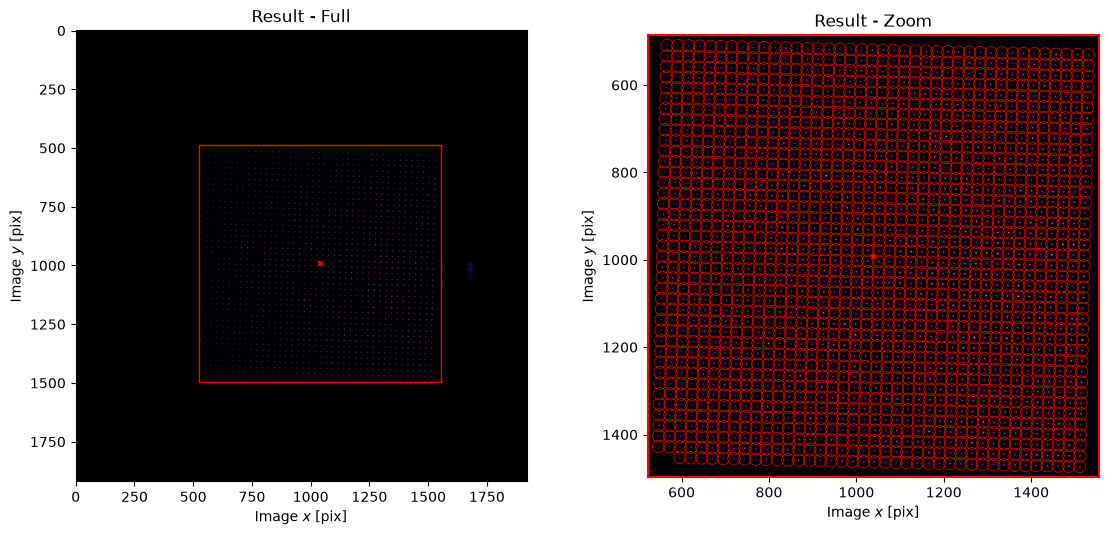

In [3]:
fs.fourier_calibrate(40, 20, autoexpose=True, plot=True);

We window the camera onto our banner, just above the SLM's undiffracted (zeroth) order,
and make a helper to load logo images into it.

In [4]:
from slmsuite.holography.analysis.files import _load_image
from slmsuite.holography.toolbox import convert_vector
from slmsuite.holography.toolbox.phase import lens

# Our blaze moves the hologram away from the SLM's undiffracted (zeroth) order, which lands
# at -blaze_freq. Light diffracts most efficiently close to the zeroth order (where the SLM
# displays its gentlest gratings), so we window the camera onto a banner just above it, leaving
# the zeroth order out of frame. The Fourier calibration is stored in raw sensor coordinates,
# so it remains valid through the change of window.
h, w = banner_shape = (640, 1280)
gap = 160       # Camera pixels between the zeroth order and the bottom of the banner.

x0, y0 = convert_vector(-np.array(blaze_freq), from_units="freq", to_units="ijraw", hardware=fs).ravel()
cam.set_woi((int(x0 - w/2), w, int(y0 - gap - h), h))

# Holograms leave everything outside the camera window free (MRAF), so the whole frame is our picture.
def load_img(name, shift=(0, 0)):
    """Loads a logo image centered on the camera frame, then shifted by (dy, dx) pixels."""
    path = os.path.join(os.getcwd(), f'../../slmsuite/docs/source/static/{name}.png')
    return _load_image(path, cam.shape, shift=shift)

[WRN] 17:40:35 FLIR Cam Attempted to set WOI to (2731, 1280, 757, 640), but realized (2728, 1280, 752, 640).


#### Planes of Focus

Optimizing a hologram at a detuned $z$ position is as simple as adding a given `propagation_kernel`
to the DFT which maps the nearfield of the SLM to the farfield. Instead of being located at exactly the depth of focus of the
system, the DFT grid will instead follow the detuned focus (and aberration) of the `propagation_kernel`.
We can make a series of holograms (comprising the three parts of our logo) at different depths.
Here, the depth is determined by the `lens(f)` phase function, which adds a lens with focal length $f$
to our system at the plane of the SLM. The case of $f=\infty$ corresponds to no lens.

In [5]:
from slmsuite.holography.algorithms import FeedbackHologram

f_eff_target = 1e7
targets = []
kernels = []
holograms = []
weights = []

# Gather three objectives for a fancy slmsuite logo.
for sym, f_eff in zip(["smith", "spin", "text"], [-f_eff_target, np.inf, f_eff_target]):
    target_ij = load_img(f"slmsuite-small-{sym}")
    kernel = lens(slm, f_eff)

    targets.append(target_ij)
    kernels.append(kernel)
    holograms.append(
        FeedbackHologram(
            (2048, 2048),
            target_ij,
            cameraslm=fs,
            propagation_kernel=kernel           # We're setting different planes of focus here with an appropriate lens().
        )
    )
    weights.append(np.linalg.norm(target_ij.astype(float)))

[INF] 17:40:35 FeedbackHologram Initialized FeedbackHologram.
[INF] 17:40:35 FeedbackHologram #2 Initialized FeedbackHologram.
[INF] 17:40:35 FeedbackHologram #3 Initialized FeedbackHologram.


This is what we loaded: three parts of a now-3D image with the encoded desired depths.

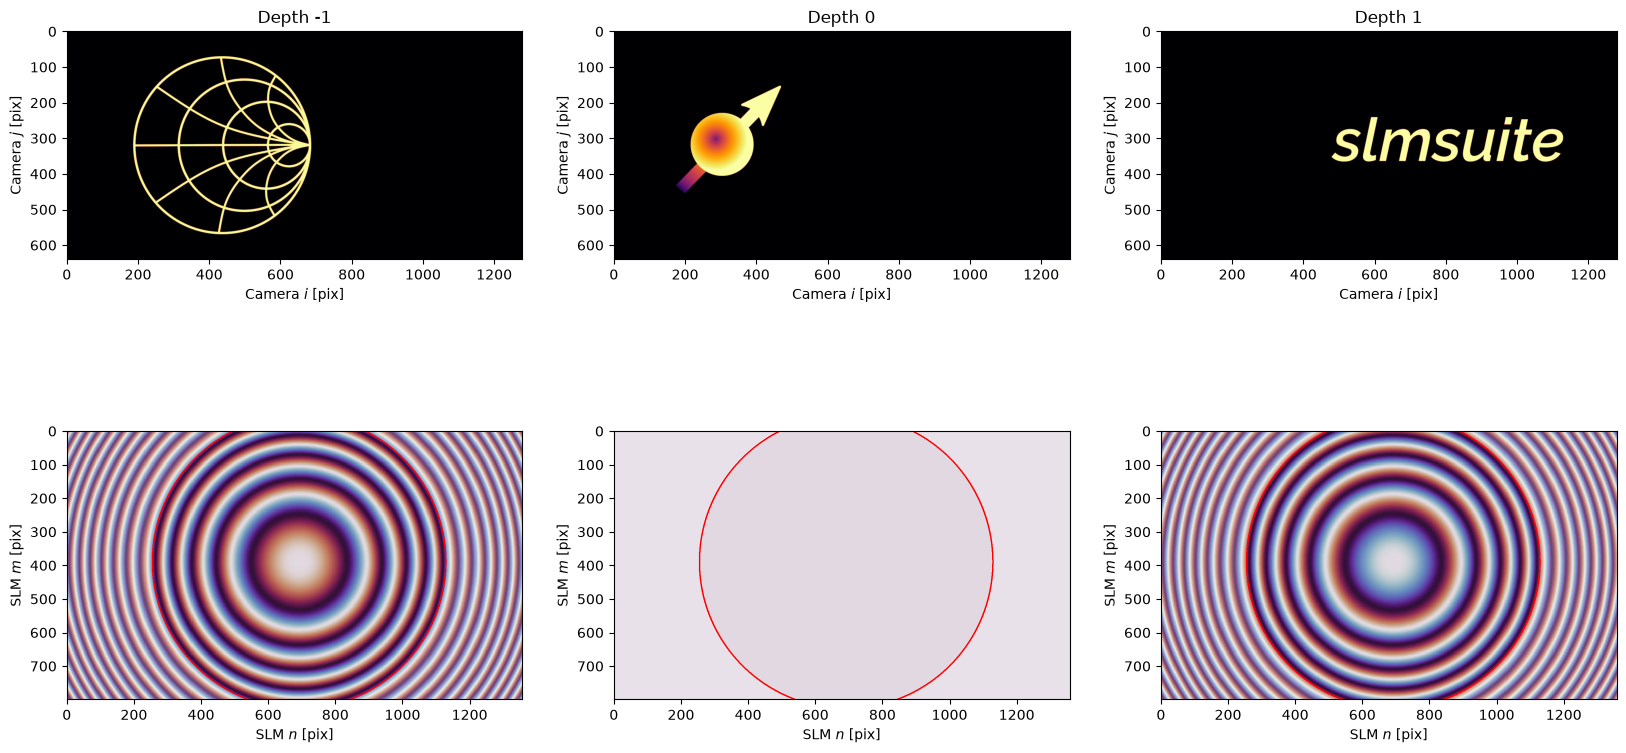

In [6]:
fig, axs = plt.subplots(2, 3, figsize=(20,10)); axs=axs.ravel()

for i, target, kernel in zip(range(3), targets, kernels):
    cam.plot(target, title=f"Depth {i-1}", ax=axs[i], cbar=False)
    slm.plot(kernel, title="", ax=axs[3+i], cbar=False)

We can now make a meta-hologram out of these `FeedbackHologram` objectives.
The `weights` factors encodes the relative weight of each objective,
as the intensity of the image is lost when each is normalized upon `FeedbackHologram` initialization.

In [7]:
from slmsuite.holography.algorithms import MultiplaneHologram

mh = MultiplaneHologram(holograms=holograms, weights=weights)

[INF] 17:40:36 MultiplaneHologram Initialized MultiplaneHologram.


Next, we optimize. Here, we initialize with a quadratic phase guess and apply MRAF to reduce speckle.

In [8]:
mh.reset_phase(random_phase=0, quadratic_phase=2)
mh.optimize(method="GS", maxiter=5, mraf_factor=1)
mh.optimize(method="WGS-Leonardo", maxiter=20, mraf_factor=.5, feedback="computational")

100%|██████████| 20/20 [00:00<00:00, 152.84it/s]


We can take a first look at our result by looking at the computational farfield.
This calls `.plot_farfield()` for each of the child holograms, and each farfield
is examined with the desired propagation kernel applied. It is this farfield
which is optimized against.

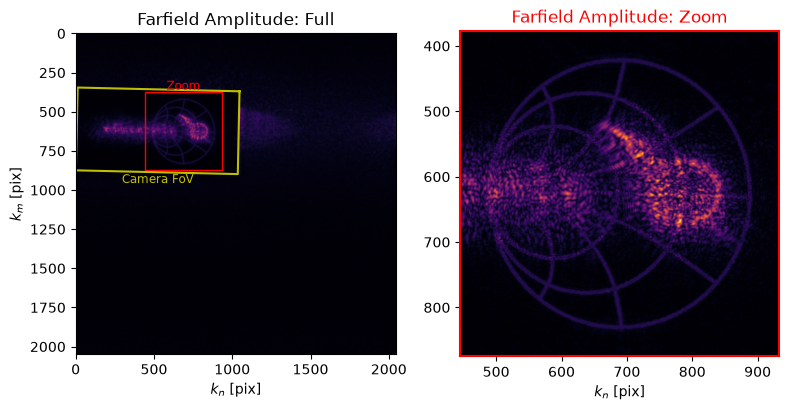

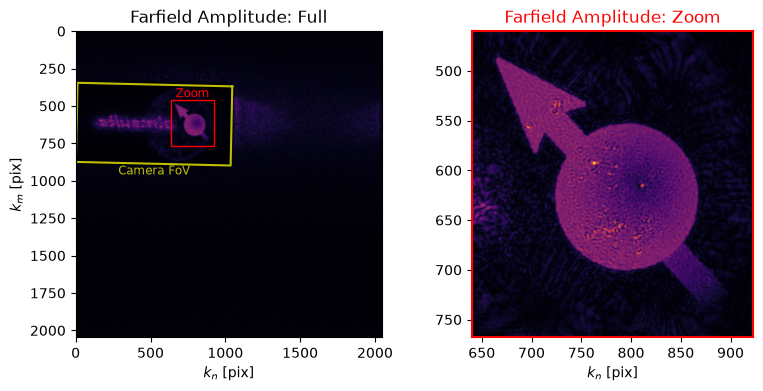

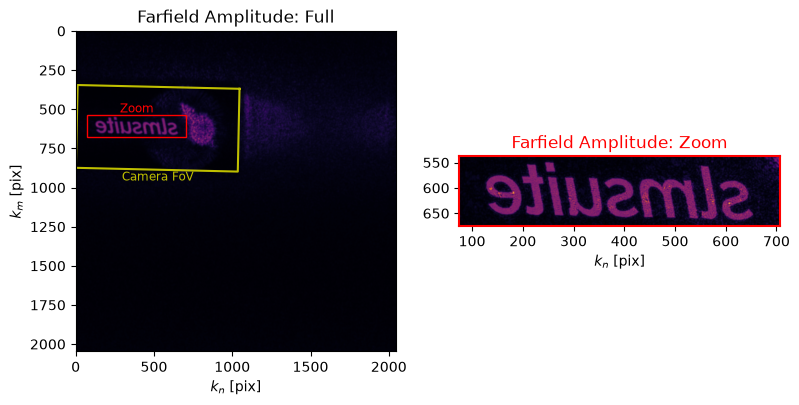

In [9]:
mh.plot_farfield()

But we can do more than this. Image feedback works the same way for multiplane holograms,
except this time the `propagation_kernel` is used to focus the spot for each experimental feedback image.
This takes a bit longer because we settle three times and capture three images (one for each plane)
during each iteration.

In [10]:
# Refine each plane with camera feedback, as in the experimental holography example.
slm.set_phase(mh.get_phase(), settle=True)
cam.autoexpose()

mh.optimize(method="WGS-Leonardo", maxiter=10, mraf_factor=.5, feedback="experimental", blur_ij=1)

[INF] 17:40:38 FLIR Cam Autoexpose: 9.99e-03 s - 2072/4095


100%|██████████| 10/10 [00:04<00:00,  2.14it/s]


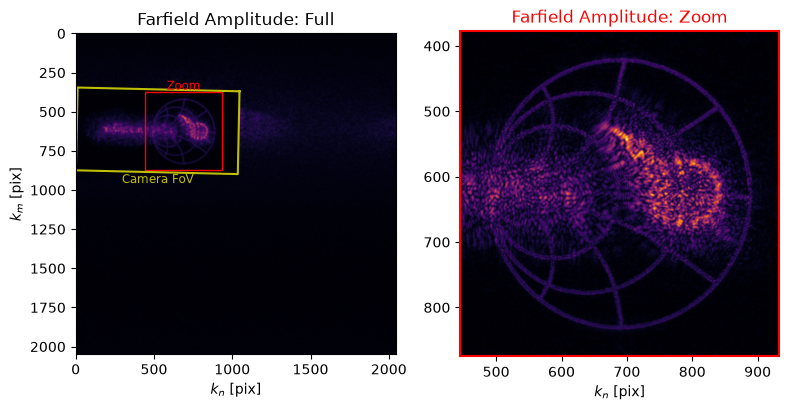

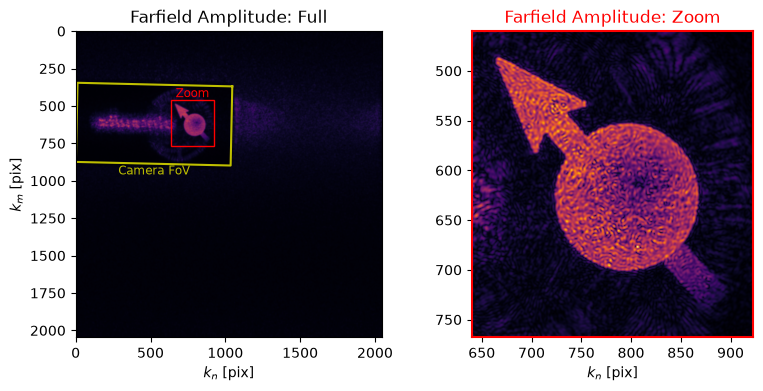

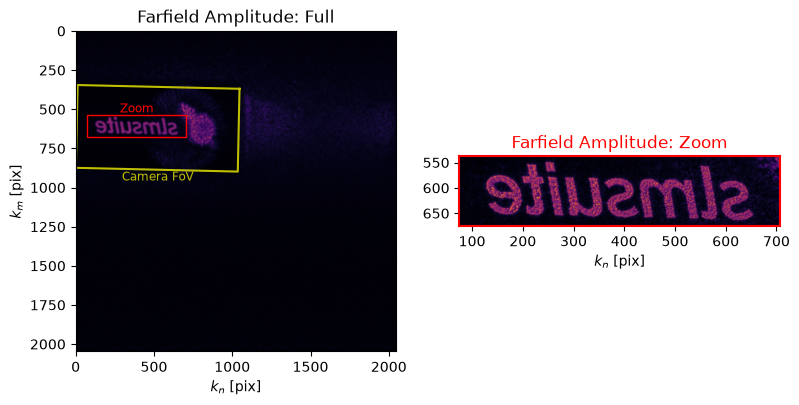

In [11]:
mh.plot_farfield()

Now let's take a look at the final result.

In [12]:
import tqdm
from slmsuite.misc.xp import as_backend

osc = (1/f_eff_target) * np.sin(np.linspace(0, 2*np.pi, 25, endpoint=False))

# Expose on the in-focus plane with headroom for the others,
# then hold the exposure so that the frames share a scale.
slm.set_phase(mh.get_phase(), settle=True)
cam.autoexpose(set_fraction=0.25)

imgs = []

with np.errstate(divide="ignore"):
    focal_lengths = np.reciprocal(osc)     # Zero power is f = inf.

for f in tqdm.tqdm(focal_lengths):
    slm.set_phase(as_backend(mh.get_phase(), slm.xp) + lens(slm, f))    # get_phase() is on the host; lens() follows the SLM.
    cam.flush()
    imgs.append(cam.get_image())

[INF] 17:40:44 FLIR Cam Autoexpose: 9.99e-03 s - 2215/4095


100%|██████████| 25/25 [00:02<00:00, 12.25it/s]


In [13]:
from slmsuite.holography.analysis.files import save_image

# Scale the colormap to saturate the brightest 1% of pixels across all frames
# (mostly the speckle of the out-of-focus planes).
vmax = int(np.percentile(imgs, 99))

save_image("ex-mutiplane.gif", imgs, cmap="Blues", lut=vmax, normalize=False, loop=0)
save_image("ex-mutiplane-dark.gif", imgs, cmap="inferno", lut=vmax, normalize=False, loop=0)

<!-- ![light](ex-mutiplane.gif)  -->
![dark](ex-mutiplane-dark.gif)

#### Planes of Basis

Alongside meta objectives consisting of many DFT holograms at different planes of focus,
we can combine DFT- and kernel/spot- based objectives in the same hologram.
This image is used for the `slmsuite` banner image on GitHub.
We first again load our image, this time in a single plane because in the end
we will want to have a static image instead of a .gif.

In [14]:
from slmsuite.holography.algorithms import FeedbackHologram

holograms = []
weights = []

# Load the logo, shifted left to leave room for the Zernike pyramids.
target_ij = load_img("slmsuite-small", shift=(0, -130))

holograms.append(
    FeedbackHologram(
        (2048, 2048),
        target_ij,
        cameraslm=fs
    )
)

[INF] 17:40:48 FeedbackHologram #4 Initialized FeedbackHologram.


For the spots, we want to make two Zernike pyramids. One is the usual that we made in a previous example.
The other makes use of a secret less-documented Zernike index `-1`. This is nonsensical as an ANSI Zernike
index, but in `slmsuite` it is the keyword for a $LG_{pl} = LG_{01}$ polynomial or vortex waveplate which produces
a bottle beam in the farfield. In the future, we might support more special keywords in the negative integers.

In [15]:
from slmsuite.holography.algorithms import CompressedSpotHologram
from slmsuite.holography.toolbox import convert_vector
from slmsuite.holography.toolbox.phase import zernike_convert_index

# Make two pyramids of order 7 in the camera basis.
N = 28
i = np.arange(N)
nl = zernike_convert_index(i, from_index="ansi", to_index="radial")
p = 25
x = cam.shape[1]/2 + 420
y = cam.shape[0]/2

vectors_ij = np.hstack((
    np.vstack((x + p * nl[:, 1], y - p * (1 + nl[:, 0] * np.sqrt(3)))),
    np.vstack((x + p * nl[:, 1], y + p * (1 + nl[:, 0] * np.sqrt(3))))
))

# Then convert to the Zernike basis and add a perturbation.
vectors_zernike_xy = convert_vector(
    vectors_ij,
    from_units="ij",
    to_units="zernike",
    hardware=fs
)

vectors_zernike = np.zeros((N,2*N))
vectors_zernike[2, :] = vectors_zernike_xy[0]
vectors_zernike[1, :] = vectors_zernike_xy[1]

perturbation = np.diag(np.ones(N))
perturbation = np.hstack((perturbation, perturbation))

vectors_zernike_pyramid = vectors_zernike + 5*perturbation

# Give the upper pyramid a LG03 term.
vectors_zernike_final = np.vstack((vectors_zernike_pyramid, np.zeros(2*N)))
vectors_zernike_final[-1, :N] = 3 # LG03
basis = np.hstack((i, [-1]))

holograms.append(
    CompressedSpotHologram(
        spot_vectors=vectors_zernike_final,
        basis=basis,
        cameraslm=fs
    )
)

[WRN] 17:40:48 holography.algorithms._spots Found ANSI index '0' (Zernike piston) in the zernike_basis; this is not necessary as spot phase is controlled externally.
[INF] 17:40:48 CompressedSpotHologram Initialized CompressedSpotHologram.


Finally, we make and optimize the meta-hologram. Here, the weights are less balanced than the previous example,
but that's expected because the Zernike pyramids need comparatively smaller power.

In [16]:
from slmsuite.holography.algorithms import MultiplaneHologram

mh = MultiplaneHologram(holograms=holograms, weights=[1, .5])

mh.reset_phase(random_phase=0, quadratic_phase=2)
mh.optimize(method="WGS-Leonardo", maxiter=10, mraf_factor=1, feedback_exponent=.8, feedback="computational")

[INF] 17:40:48 MultiplaneHologram #2 Initialized MultiplaneHologram.


100%|██████████| 10/10 [00:00<00:00, 20.29it/s]


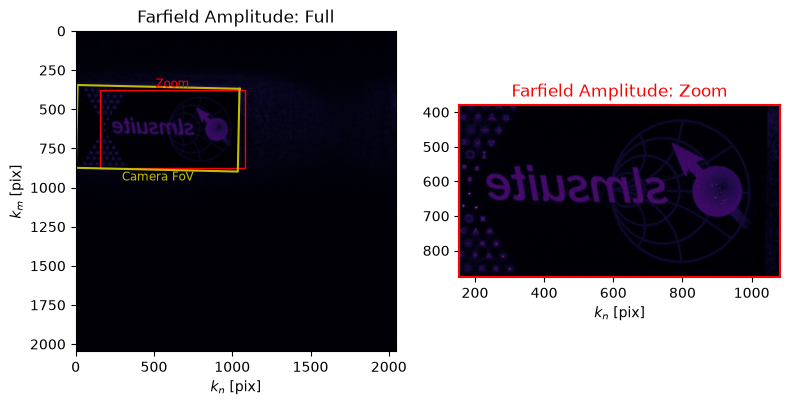

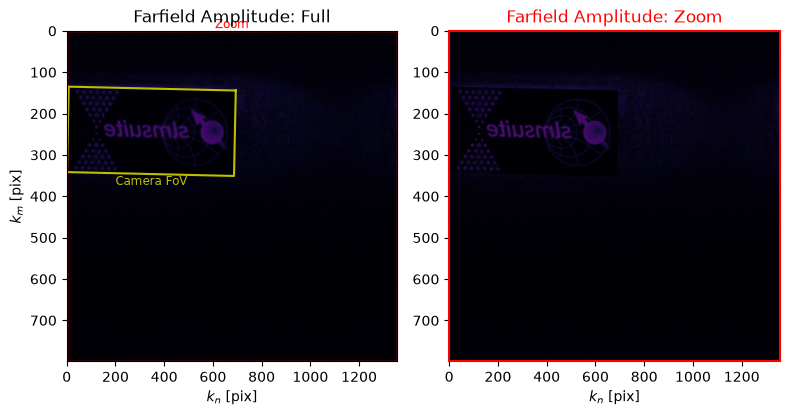

In [17]:
mh.plot_farfield()

In [18]:
# Refine the logo with camera feedback, as in the experimental holography example. The Zernike
# spots stay on computational feedback, as in the Zernike example, since these aberrated spots
# overflow the windows that "experimental_spot" feedback integrates. MultiplaneHologram passes
# the same flags to every child, so a callback (run before each weight update) resets the spots.
def spots_computational(mh):
    for hologram in mh.holograms:
        if isinstance(hologram, CompressedSpotHologram):
            hologram.flags["feedback"] = "computational_spot"

slm.set_phase(mh.get_phase(), settle=True)
cam.autoexpose(set_fraction=0.8)

mh.optimize(method="WGS-Leonardo", maxiter=10, mraf_factor=.5, feedback="experimental", blur_ij=1, callback=spots_computational)

[INF] 17:40:50 FLIR Cam Autoexpose: 4.33e-03 s - 2038/4095


100%|██████████| 10/10 [00:01<00:00,  6.78it/s]


Now let's collect the banner!

[INF] 17:40:52 FLIR Cam Autoexpose: 2.25e-02 s - 2043.0/4095


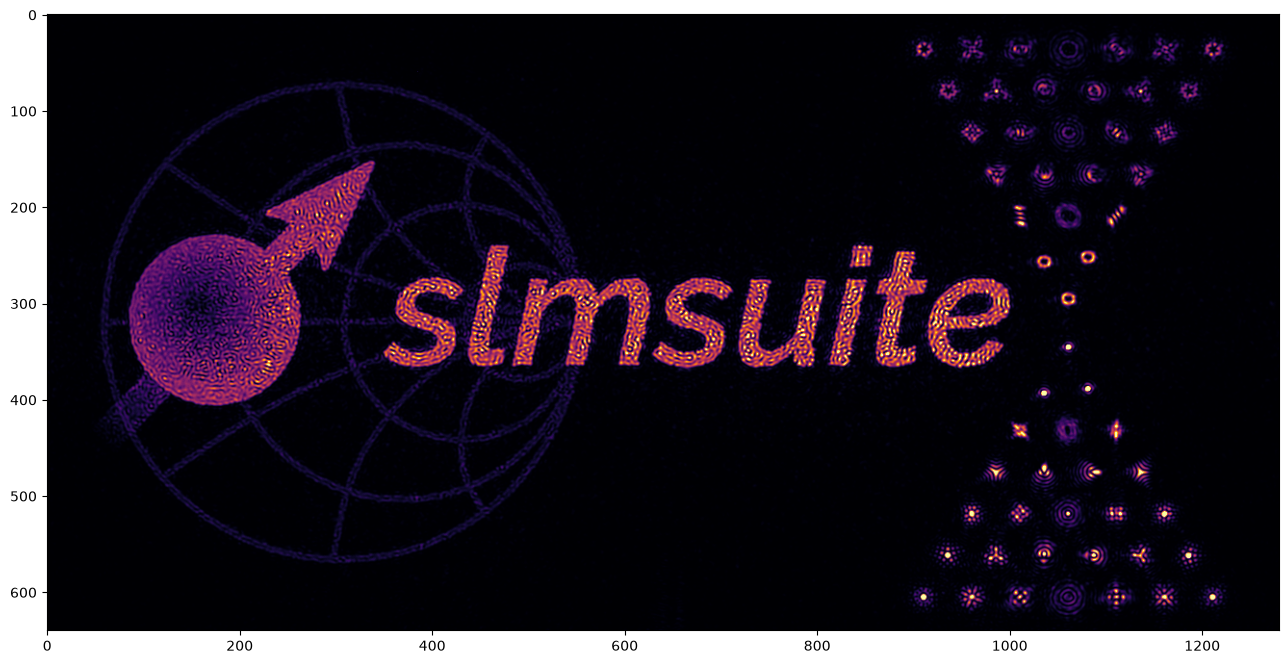

In [19]:
# Expose on the logo rather than the brightest pixel, letting the cores of the
# sharpest Zernike spots (the brightest 0.1% of the banner) saturate.
slm.set_phase(mh.get_phase(), settle=True)
cam.autoexpose(set_fraction=1, metric=lambda img: np.percentile(img, 99.9))
banner = cam.get_image()

plt.figure(figsize=(16,8))
plt.imshow(banner)
plt.show()

save_image("slmsuite-banner.png", banner, cmap=True, border=127)

#### Planes of Both

As a final example hologram, let's combine the two previous cases.
We want to make the 3D `slmsuite` logo moving through a starfield of bottle beams.

In [20]:
from slmsuite.holography.algorithms import FeedbackHologram

f_eff_target = 1e7
targets = []
kernels = []
holograms = []
weights = []

# Gather three objectives for a fancy slmsuite logo.
for sym, f_eff in zip(["smith", "spin", "text"], [-f_eff_target, np.inf, f_eff_target]):
    target_ij = load_img(f"slmsuite-small-{sym}")
    kernel = lens(slm, f_eff)

    targets.append(target_ij)
    kernels.append(kernel)
    holograms.append(
        FeedbackHologram(
            (2048, 2048),
            target_ij,
            cameraslm=fs,
            propagation_kernel=kernel           # We're setting different planes of focus here with an appropriate lens().
        )
    )

    weights.append(np.linalg.norm(target_ij.astype(float)))

[INF] 17:40:52 FeedbackHologram #5 Initialized FeedbackHologram.
[INF] 17:40:52 FeedbackHologram #6 Initialized FeedbackHologram.
[INF] 17:40:52 FeedbackHologram #7 Initialized FeedbackHologram.


Now we move onto the bottle beams. We use the same ANSI index `-1` as before to add a
vortex waveplate term to the Zernike basis.
For clarity, we also tell the spots to avoid the DFT holograms via blurring and each other via `lloyds_algorithm()`.

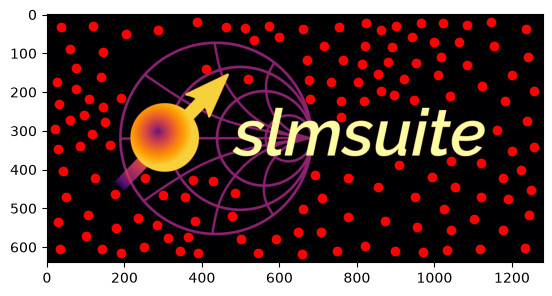

[INF] 17:40:52 CompressedSpotHologram #2 Initialized CompressedSpotHologram.


In [21]:
import cv2
from slmsuite.holography.algorithms import CompressedSpotHologram
from slmsuite.holography.toolbox import lloyds_algorithm
from slmsuite.holography.analysis import _generate_grid

# Scatter stars across the frame, spread out evenly with `lloyds_algorithm()`.
N_spots = 200
spots_ij = np.vstack((
    np.random.randint(0, cam.shape[1], size=N_spots),
    np.random.randint(0, cam.shape[0], size=N_spots)
))
spots_ij = lloyds_algorithm(_generate_grid(cam.shape[1], cam.shape[0]), spots_ij, iterations=2).astype(int)

# Keep the stars that are clear of the logo and of the edges of the frame.
target_ij = load_img("slmsuite-small")
target_ij_blur = cv2.GaussianBlur(target_ij.astype(np.uint8), (61,61), 0)

margin = 20
keep = np.logical_and(
    target_ij_blur[spots_ij[1], spots_ij[0]] == 0,
    np.all((spots_ij >= margin) & (spots_ij < np.array([[cam.shape[1]], [cam.shape[0]]]) - margin), axis=0)
)
spots_ij = spots_ij[:, keep]
N_spots = spots_ij.shape[1]

plt.imshow(target_ij)
plt.scatter(spots_ij[0], spots_ij[1], c="r")
plt.show()

# Convert to kxy units so we can add on depth in units of focal power.
spots_kxy = convert_vector(
    spots_ij,
    from_units="ij",
    to_units="kxy",
    hardware=fs
)

spots_kxyz = np.vstack((
    spots_kxy,
    2 * (np.random.rand(N_spots) - .5) / f_eff_target
))

# Finally, convert to zernike.
spots_zernike = convert_vector(
    spots_kxyz,
    from_units="kxy",
    to_units="zernike",
    hardware=fs
)

# Turn every spot into a bottle beam.
basis = [
    2,      # x
    1,      # y
    4,      # z
    -1      # LG10 - vortex waveplate
]

spots_zernike = np.vstack((
    spots_zernike,
    2 * np.ones((1, N_spots))   # LG20 on every spot, for fun.
))

# Make the spot hologram.
holograms.append(
    CompressedSpotHologram(
        spot_vectors=spots_zernike,
        basis=basis,
        cameraslm=fs
    )
)
weights.append(1000)

Making the hologram, optimizing, and monitoring the result is as simple as before:

In [22]:
from slmsuite.holography.algorithms import MultiplaneHologram

mh = MultiplaneHologram(holograms=holograms, weights=weights)

mh.reset_phase(random_phase=0, quadratic_phase=2)
mh.optimize(method="GS", maxiter=5, mraf_factor=1)
mh.optimize(method="WGS-Leonardo", maxiter=20, mraf_factor=1, feedback="computational")

[INF] 17:40:52 MultiplaneHologram #3 Initialized MultiplaneHologram.


100%|██████████| 20/20 [00:00<00:00, 161.54it/s]


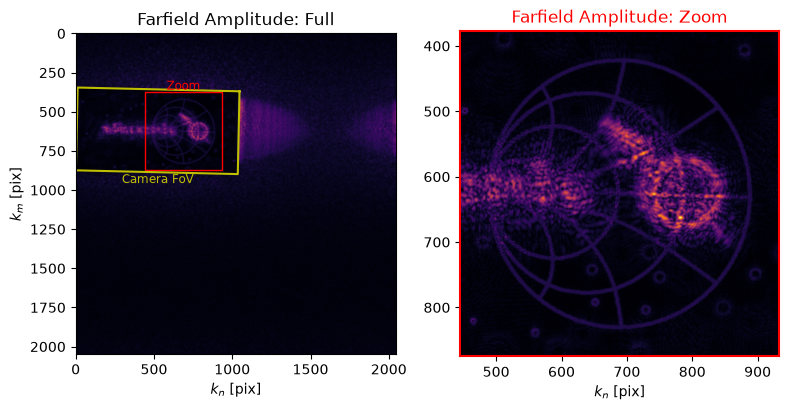

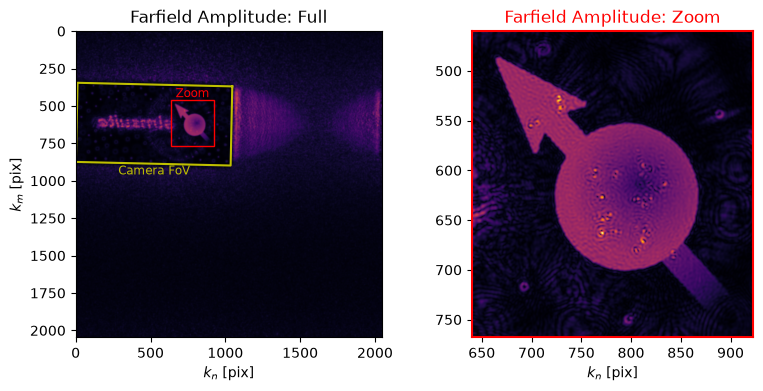

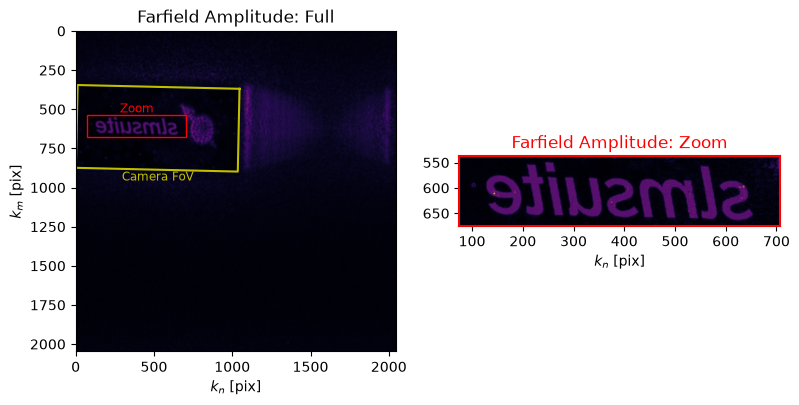

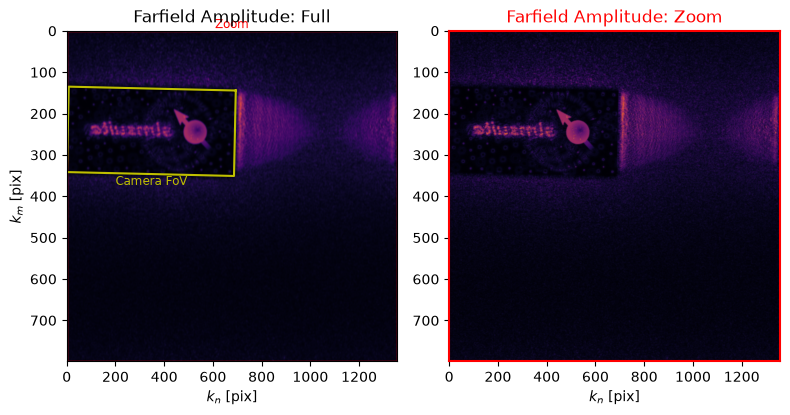

In [23]:
mh.plot_farfield()

In [24]:
# As for the banner, the logo takes camera feedback while the stars stay on computational feedback:
# most are out of focus on the camera, where "experimental_spot" cannot measure them.
slm.set_phase(mh.get_phase(), settle=True)
cam.autoexpose()

mh.optimize(method="WGS-Leonardo", maxiter=10, mraf_factor=.5, feedback="experimental", blur_ij=1, callback=spots_computational)

[INF] 17:40:56 FLIR Cam Autoexpose: 2.44e-02 s - 2015/4095


100%|██████████| 10/10 [00:06<00:00,  1.66it/s]


We again collect the spots, oscillating in $z$.

In [25]:
from tqdm import tqdm
from slmsuite.misc.xp import as_backend

osc = (1/f_eff_target) * np.sin(np.linspace(0, 2*np.pi, 25, endpoint=False))

# Expose on the in-focus plane with headroom for the others,
# then hold the exposure so that the frames share a scale.
slm.set_phase(mh.get_phase(), settle=True)
cam.autoexpose(set_fraction=0.25)

imgs = []

with np.errstate(divide="ignore"):
    focal_lengths = np.reciprocal(osc)     # Zero power is f = inf.

for f in tqdm(focal_lengths):
    slm.set_phase(as_backend(mh.get_phase(), slm.xp) + lens(slm, f))    # get_phase() is on the host; lens() follows the SLM.
    cam.flush()
    imgs.append(cam.get_image())

[INF] 17:41:02 FLIR Cam Autoexpose: 1.10e-02 s - 2075/4095


100%|██████████| 25/25 [00:02<00:00, 12.02it/s]


In [26]:
from slmsuite.holography.analysis.files import save_image

# The .gifs are a bit large at raw resolution for GitHub unfortunately, so we downscale by 2x
N = 2
imgs = np.array(imgs)
imgs2 = 0

for x in range(N):
    for y in range(N):
        imgs2 += imgs[:, x::N, y::N] // (N * N)

# Scale the colormap to saturate the brightest 1% of pixels across all frames
# (mostly the speckle of the out-of-focus planes).
vmax = int(np.percentile(imgs2, 99))

save_image("ex-slmsuite-3d.gif", imgs2, cmap="Blues", lut=vmax, border=127, normalize=False, loop=0)
save_image("ex-slmsuite-3d-dark.gif", imgs2, cmap="inferno", lut=vmax, border=127, normalize=False, loop=0)

<!-- ![light](ex-slmsuite-3d.gif)  -->
![dark](ex-slmsuite-3d-dark.gif)

Looking at this hologram directly by eye reveals all the depth cues that are lost by 
image capture on a camera. These depth cues are important for AR/VR applications.

#### Afterword

Altogether, `MultiplaneHologram` enhances the versatility of holography with `slmsuite`.
Wherever the user is interested in the state of the farfield, at whichever focus or color,
the user can wrest control in the form of DFT grids or spots in aberration-space.

We look forward to seeing the novel combinations of objectives you will create!

In [27]:
slm.close()
cam.close()